# KNN IMPUTER

---

In [49]:
import numpy as np
import pandas as pd 

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from sklearn.impute import KNNImputer,SimpleImputer
from sklearn.linear_model import LogisticRegression

In [50]:
df = pd.read_csv(r"D:\ML\DataSet\Titanic_Dataset.csv")[['Age','Pclass','Fare','Survived']]

the technique we have used is other way to use usecols as in this way we pass a list and in that we again pass a list of the name of the columns in the order we wanted to keep in the columns in the dataFrame

this is a imp. trick so learn it.

In [51]:
df.head(3)

,Age,Pclass,Fare,Survived
0,22.0,3,7.2500,0
1,38.0,1,71.2833,1
2,26.0,3,7.9250,1


In [52]:
df.isnull().mean()*100

Age         19.86532
Pclass       0.00000
Fare         0.00000
Survived     0.00000
dtype: float64

In [53]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [54]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [55]:
X_train.head(3)

,Age,Pclass,Fare
331,45.5,1,28.500
733,23.0,2,13.000
382,32.0,3,7.925


In [56]:
X_train.shape,X_test.shape

((712, 3), (179, 3))

In [57]:
knn = KNNImputer(n_neighbors=5)     #this give us to change the no.s of K in knn

X_train_trf = knn.fit_transform(X_train)
X_test_trf = knn.transform(X_test)

In [58]:
pd.DataFrame(X_train_trf,columns=X_train.columns)   #this is the way to create a dataframe with the data 
# from x_train_trf and the column from original X_train 

,Age,Pclass,Fare
0,45.5,1.0,28.5000
1,23.0,2.0,13.0000
2,32.0,3.0,7.9250
3,26.0,3.0,7.8542
4,6.0,3.0,31.2750
...,...,...,...
707,21.0,3.0,7.6500
708,39.0,1.0,31.0000
709,41.0,3.0,14.1083
710,14.0,1.0,120.0000


now after applying the knn the missing value gets disappear but - but now lets train a model on this new data X_train_trf and see the impact by accuracy score

In [59]:
lr = LogisticRegression()

lr.fit(X_train_trf,y_train)
y_pred = lr.predict(X_test_trf)

accuracy_score(y_test,y_pred)

0.7430167597765364

---

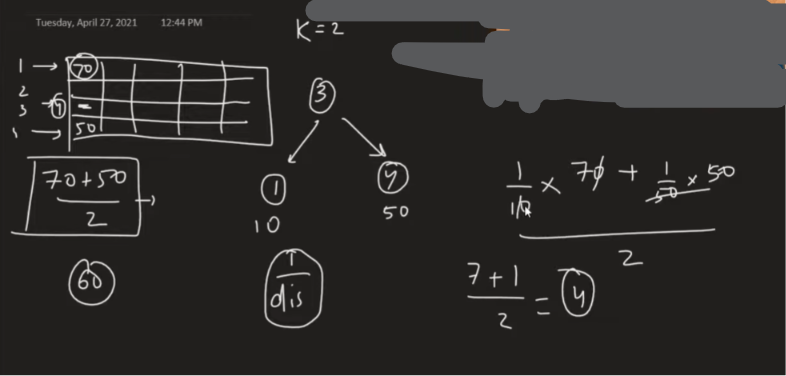

this "distance" in "weight" represents the method in which we will find the missing value using the nearest neighbours as we in this case multiply the value of row1 with 1/(distance from row3) and then do the same for other row4 and then add those and dividing by k to get the missing value instead of just summing the no. and then taking avg.

In [60]:
knn = KNNImputer(n_neighbors=5,weights='distance')

X_train_trf = knn.fit_transform(X_train)
X_test_trf = knn.transform(X_test)

In [61]:
pd.DataFrame(X_train_trf,columns=X_train.columns) 

,Age,Pclass,Fare
0,45.500000,1.0,28.5000
1,23.000000,2.0,13.0000
2,32.000000,3.0,7.9250
3,26.000000,3.0,7.8542
4,6.000000,3.0,31.2750
...,...,...,...
707,21.000000,3.0,7.6500
708,40.111111,1.0,31.0000
709,41.000000,3.0,14.1083
710,14.000000,1.0,120.0000


In [62]:
lr = LogisticRegression()

lr.fit(X_train_trf,y_train)
y_pred = lr.predict(X_test_trf)

accuracy_score(y_test,y_pred)

0.7374301675977654

important note -> while training or doing transformations we dont give the y values under the transformation but when the time comes for the model training then we sends both the X and Y components

In [64]:
# Comparision with Simple Imputer --> mean

si = SimpleImputer()

X_train_trf2 = si.fit_transform(X_train)
X_test_trf2 = si.transform(X_test)

In [65]:
lr = LogisticRegression()

lr.fit(X_train_trf2,y_train)

y_pred2 = lr.predict(X_test_trf2)

accuracy_score(y_test,y_pred2)

0.7374301675977654

---